In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from utils import *
from pylops.basicoperators import *

In [2]:
moomba_test_path = './data/test_cubes/F3_test_2.npy'
Unet_pred_path = './notebook/results/unet_pred_f3_2_ratio0.7_random.npy'
UFNO_pred_path = './notebook/results/ufno_pred_f3_2_ratio0.7_random.npy'
label = np.load(f'{moomba_test_path}')
Unet_pred = np.load(f'{Unet_pred_path}')
UFNO_pred = np.load(f'{UFNO_pred_path}')
Convention_pred = np.copy(Unet_pred)

<Figure size 600x600 with 0 Axes>

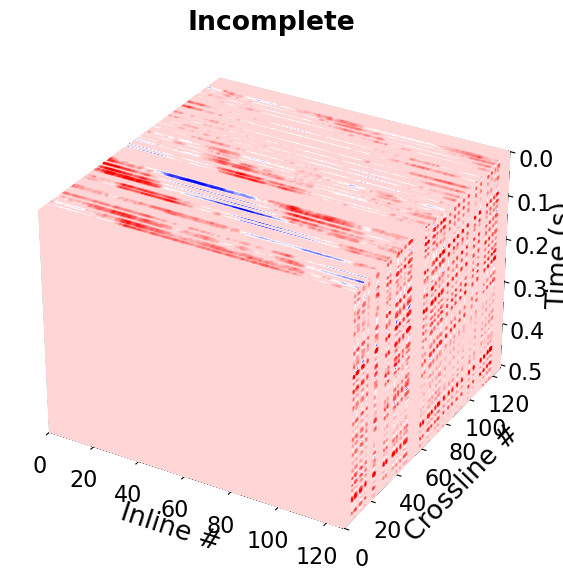

In [3]:
# [in1, in2, in3] = label.shape
# # the ratio of missing trace equal to 1-ratio
# ratio = 0.25

# ## build the input data
# [in1, in2, in3] = label.shape
# ## generate random mask
# iava, iavarec = irregular2(in1, in2, in3, perc_sub=ratio, seed=10)
# # Create restriction operator
# Rop = Restriction(dims=in1*in2*in3, iava=iava, dtype='float64')
# datamasked = Rop.H*Rop*label.ravel()
# mask = Rop.H*Rop*np.ones_like(label).ravel()
# mask = mask.reshape(in1, in2, in3)
# frand_mask_cube = label.T*mask
# test_data = frand_mask_cube.T

[in1, in2, in3] = label.shape
# the ratio of missing trace equal to 1-ratio
ratio = 0.3

## generate random mask
mask=genmask(label.reshape(in2,in1*in3,order='F'),ratio,'r',202412)
mask=mask.reshape(in1,in2,in3,order='F')
rand_mask_cube = label*mask.T
test_data = rand_mask_cube


cube_visual(test_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)",
            title='Incomplete', save_path='False')

In [4]:
# Define spatial parameters
deltaz = 0.004
deltax = deltay = 1
zmin = xmin = ymin = 0

cube_shape = label.shape
xmax = cube_shape[0] * deltax
ymax = cube_shape[1] * deltay
zmax = cube_shape[2] * deltaz

# Generate coordinate arrays
x = np.linspace(xmin, xmax, cube_shape[0], endpoint=True)
y = np.linspace(ymin, ymax, cube_shape[1], endpoint=True)
z = np.linspace(zmin, zmax, cube_shape[2], endpoint=True)
print(x.shape)

# Create meshgrid
Z, X, Y = np.meshgrid(z, x, y, indexing='ij')

(128,)


In [5]:
import pyortho as lo #lo: local orthogonalization

## prepare paramters for ortho
rect=[10,10,10];
eps=0;
niter=20;
verb=1;


simi_unet=lo.localsimic(label,label-Unet_pred,[5,5,5],niter,eps,verb);
simi_ufno=lo.localsimic(label,label-UFNO_pred,[5,5,5],niter,eps,verb);
simi_convention=lo.localsimic(label,label-Convention_pred,[5,5,5],niter,eps,verb);

128 128 128 5 5 5 20 0 1
128 128 128 5 5 5 20 0 1
128 128 128 5 5 5 20 0 1
n1=128,n2=128,n3=128,r1=5,r2=5,r3=5
niter=20,eps=0,verb=1
dim=3,dim1=2
nd=2097152
iteration 0 res: 0.998399 grad: 0.000000
iteration 1 res: 0.939479 grad: 0.568160
iteration 2 res: 0.901073 grad: 0.456828
iteration 3 res: 0.857154 grad: 0.375787
iteration 4 res: 0.821465 grad: 0.234801
iteration 5 res: 0.801247 grad: 0.144004
iteration 6 res: 0.789977 grad: 0.097784
iteration 7 res: 0.782223 grad: 0.054819
iteration 8 res: 0.777306 grad: 0.035033
iteration 9 res: 0.774447 grad: 0.024754
iteration 10 res: 0.772664 grad: 0.015236
iteration 11 res: 0.771667 grad: 0.011336
iteration 12 res: 0.771202 grad: 0.007111
iteration 13 res: 0.770899 grad: 0.004522
iteration 14 res: 0.770679 grad: 0.003204
iteration 15 res: 0.770515 grad: 0.002466
iteration 16 res: 0.770322 grad: 0.001637
iteration 17 res: 0.770162 grad: 0.001242
iteration 18 res: 0.769999 grad: 0.000676
iteration 19 res: 0.769857 grad: 0.000486
iteration 0 r

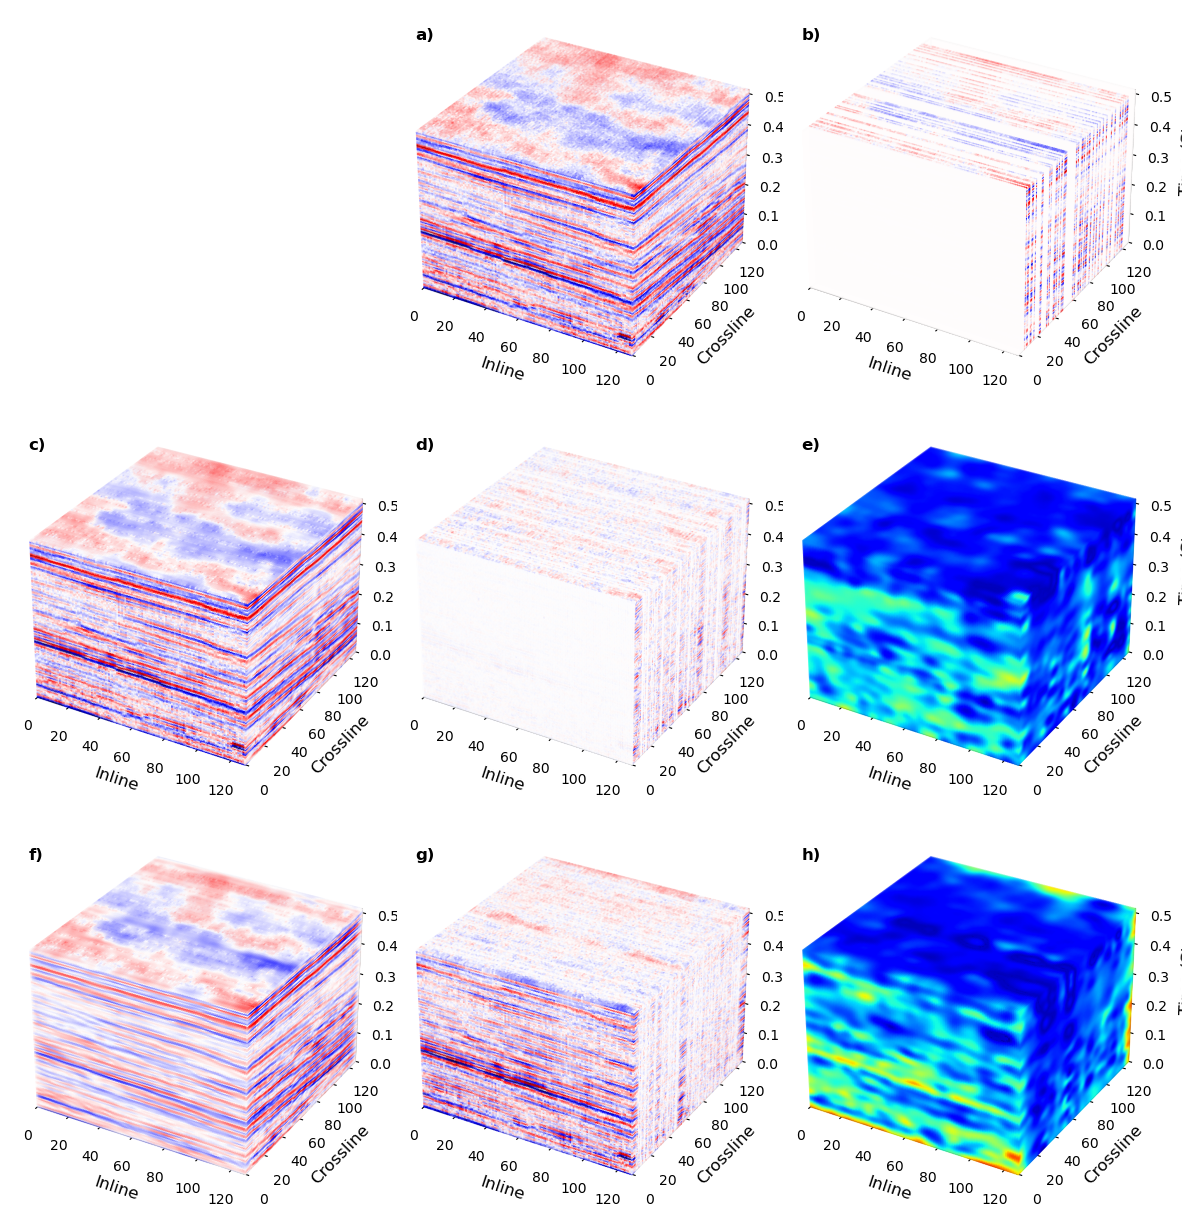

In [6]:
# Data for visualization
data = [
    label, test_data, UFNO_pred, (label - UFNO_pred), simi_ufno, Unet_pred,
    (label - Unet_pred), simi_unet
]

# Create figure with smaller size
fig = plt.figure(figsize=(12, 12))

# Create subplots with scatter plotting
for i in range(8):
    ax = fig.add_subplot(3, 3, i + 2, projection='3d')
    # Downsample heavily for speed (every 20th point)
    step = 1
    idx = np.arange(0, data[i].size, step)
    # Use jet colormap for figures e and h (indices 4 and 7 for Simi UFNO and Simi Unet)
    if i in [4, 7]:  # Simi UFNO and Simi Unet
        ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='jet', vmin=0, vmax=1.2, s=0.5
        )
    else:
        ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='seismic', vmin=-4, vmax=4, s=0.5
        )
    # Set axis labels with smaller fontsize
    ax.set_xlabel('Inline', fontsize=12)
    ax.set_ylabel('Crossline', fontsize=12)
    ax.set_zlabel('Time (S)', fontsize=12)
    # Set tick label fontsize
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.invert_zaxis()
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.text2D(0.05, 0.95, f"{chr(97 + i)})", transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)

# Adjust layout
fig.subplots_adjust(left=0.0, right=0.96, top=1, bottom=0.01, wspace=0.02, hspace=0.11)

# Save figure
plt.savefig(f'./figs/tgrs_results/F3_test_ratio{1-ratio}_missing_comp.png')

plt.show()

In [10]:
# plt.savefig(f'./figs/tgrs_results/F3_test_ratio{1-ratio}_missing_comp.png')

<Figure size 800x600 with 0 Axes>

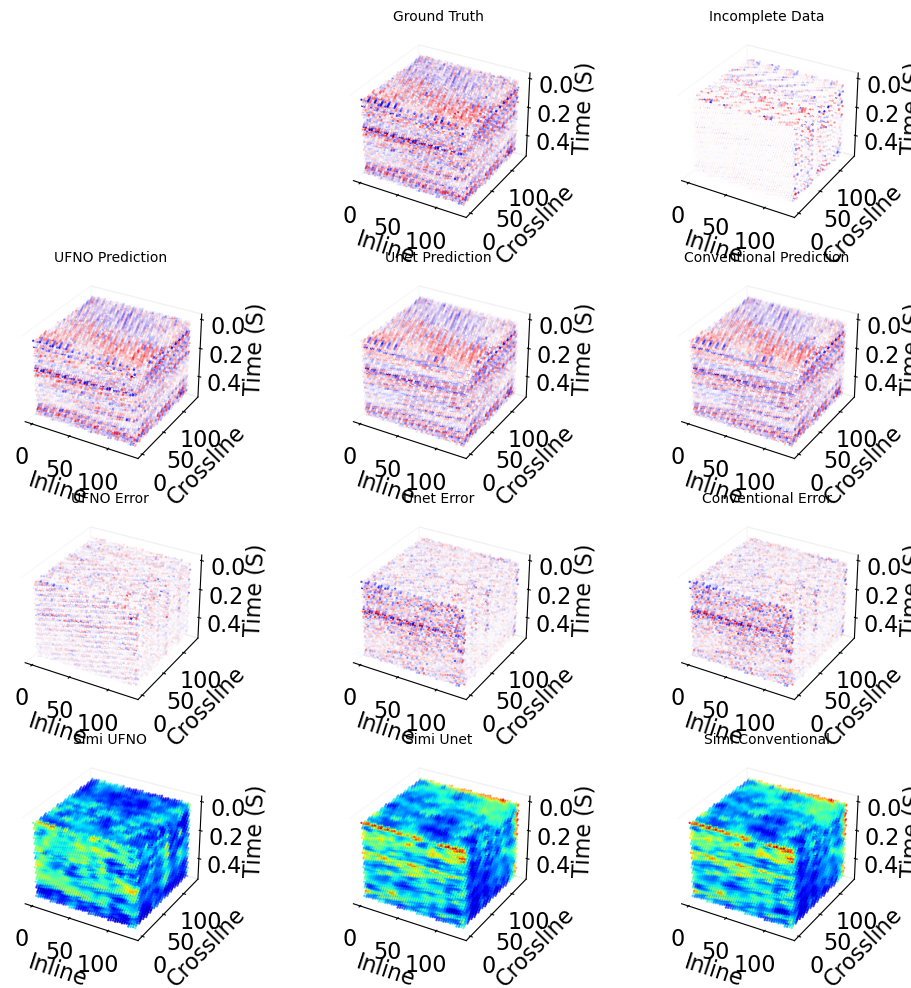

In [6]:
# Data for visualization
data = [
    label, test_data, UFNO_pred, Unet_pred, Convention_pred,
    (label - UFNO_pred), (label - Unet_pred), (label - Convention_pred),
    simi_ufno, simi_unet, simi_convention
]
titles = [
    'Ground Truth', 'Incomplete Data', 'UFNO Prediction', 'Unet Prediction',
    'Conventional Prediction', 'UFNO Error', 'Unet Error', 'Conventional Error',
    'Simi UFNO', 'Simi Unet', 'Simi Conventional'
]

# Create figure
fig = plt.figure(figsize=(12, 12))

# Create subplots with scatter plotting
seismic_sc = None
simi_sc = None
for i in range(11):
    ax = fig.add_subplot(4, 3, i + 2, projection='3d')
    # Downsample for speed (every 10th point)
    step = 25
    idx = np.arange(0, data[i].size, step)
    # Scatter plot with appropriate colormap
    if i >= 8:  # Last three subplots (Simi UFNO, Simi Unet, Simi Conventional)
        sc = ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='jet', vmin=0, vmax=1, s=0.5
        )
        if i == 8:  # Store scatter object for similarity colorbar
            simi_sc = sc
    else:
        sc = ax.scatter(
            X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
            c=data[i].flatten()[idx], cmap='seismic', vmin=-5, vmax=5, s=0.5
        )
        if i == 0:  # Store scatter object for seismic colorbar
            seismic_sc = sc
    ax.set_xlabel('Inline')
    ax.set_ylabel('Crossline')
    ax.set_zlabel('Time (S)')
    ax.set_title(titles[i], fontsize=10)
    ax.invert_zaxis()
    # Remove grid/mesh
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# # Add colorbar for seismic data
# cbar_seismic = fig.colorbar(seismic_sc, ax=fig.get_axes(), location='right', shrink=0.2, pad=0.05)
# cbar_seismic.set_label('Amplitude', fontsize=10)

# # Add colorbar for similarity data
# cbar_simi = fig.colorbar(simi_sc, ax=fig.get_axes(), location='bottom', shrink=0.2, pad=0.05)
# cbar_simi.set_label('Similarity', fontsize=10)

# Adjust layout
# plt.tight_layout()


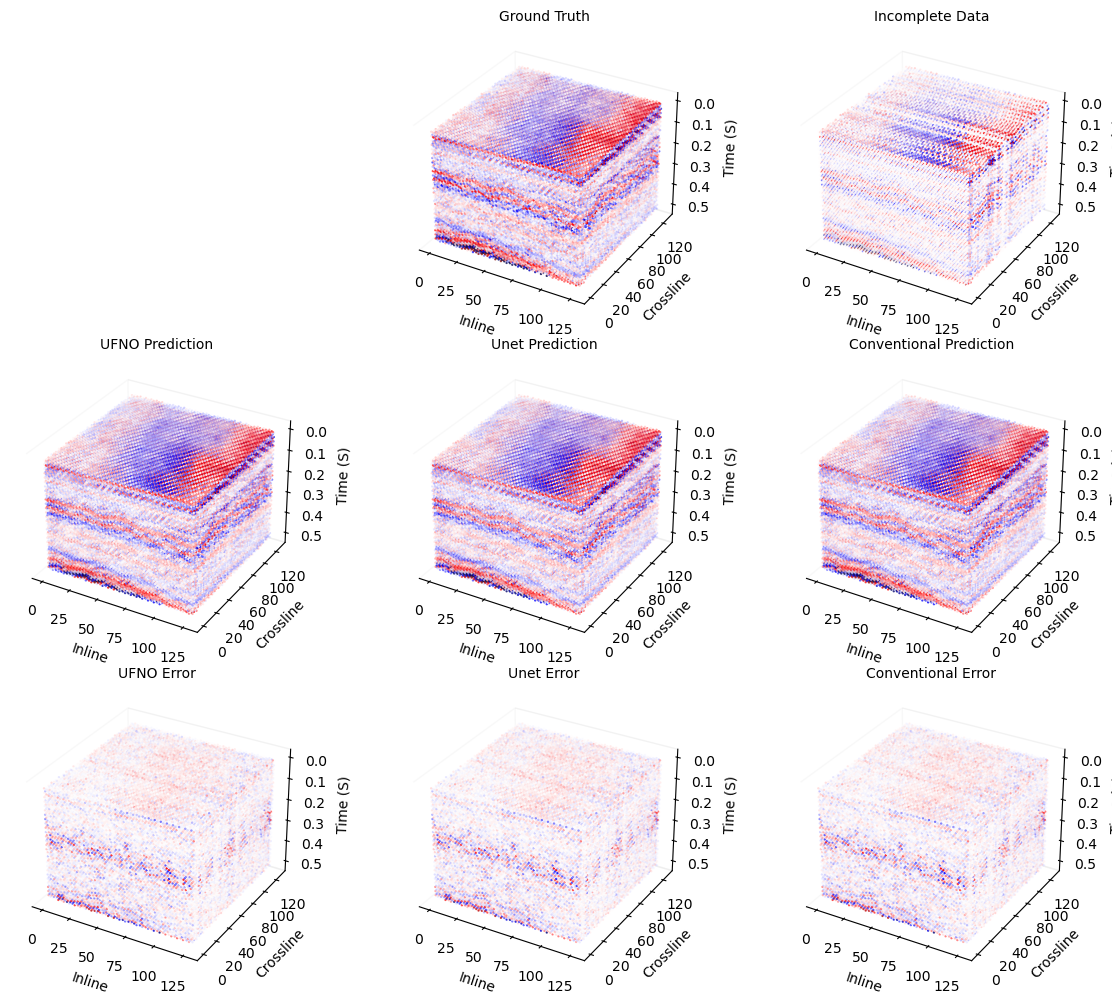

In [6]:
# Data for visualization
data = [
    label, test_data, UFNO_pred, Unet_pred, Convention_pred,
    (label - UFNO_pred), (label - Unet_pred), (label - Convention_pred)
]
titles = [
    'Ground Truth', 'Incomplete Data', 'UFNO Prediction', 'Unet Prediction',
    'Conventional Prediction', 'UFNO Error', 'Unet Error', 'Conventional Error'
]

# Create figure
fig = plt.figure(figsize=(12, 10))

# Create subplots with scatter plotting
for i in range(8):
    ax = fig.add_subplot(3, 3, i + 2, projection='3d')
    # Downsample for speed (every 10th point for balance)
    step = 10
    idx = np.arange(0, data[i].size, step)
    ax.scatter(
        X.flatten()[idx], Y.flatten()[idx], Z.flatten()[idx],
        c=data[i].flatten()[idx], cmap='seismic', vmin=-5, vmax=5, s=0.5
    )
    ax.set_xlabel('Inline')
    ax.set_ylabel('Crossline')
    ax.set_zlabel('Time (S)')
    ax.set_title(titles[i], fontsize=10)
    ax.invert_zaxis()
    # Remove grid/mesh
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# Adjust layout
plt.tight_layout()
